In [2]:
import pandas as pd
import altair as alt
import numpy as np
alt.data_transformers.enable("vegafusion")

DataTransformerRegistry.enable('vegafusion')

In [7]:
df = pd.read_csv("../../data/anime-filtered.csv")

# Explode the Genres column to assign each anime to multiple genres
df_exploded = df.assign(Genres=df['Genres'].str.split(', ')).explode('Genres')

# Count the frequency of each genre and select the top 10 most frequent ones
top_genres = df_exploded['Genres'].value_counts().head(10).index

# Filter dataset to include only the top 10 genres
df_exploded = df_exploded[df_exploded['Genres'].isin(top_genres)]

# Select relevant numerical columns
columns = ['Score', 'Members', 'Popularity', 'Completed', 'On-Hold', 'Dropped']

# Aggregate by genre, computing the mean for each variable
df_genre_avg_original = df_exploded.groupby('Genres')[columns].mean().reset_index()

# Store the original mean data before normalization
df_genre_avg = df_genre_avg_original.copy()

# Normalize values for better visualization (Min-Max Scaling)
df_genre_avg[columns] = (df_genre_avg[columns] - df_genre_avg[columns].min()) / \
                        (df_genre_avg[columns].max() - df_genre_avg[columns].min())

json_data = [
    {
        "genre": row["Genres"],
        "Score": round(row["Score"], 3),
        "Members": round(row["Members"], 3),
        "Popularity": round(row["Popularity"], 3),
        "Completed": round(row["Completed"], 3),
        "OnHold": round(row["On-Hold"], 3),
        "Dropped": round(row["Dropped"], 3),
    }
    for _, row in df_genre_avg.iterrows()
]

json_data

[{'genre': 'Action',
  'Score': 0.262,
  'Members': 0.518,
  'Popularity': 0.512,
  'Completed': 0.527,
  'OnHold': 0.558,
  'Dropped': 0.593},
 {'genre': 'Adventure',
  'Score': 0.243,
  'Members': 0.099,
  'Popularity': 1.0,
  'Completed': 0.146,
  'OnHold': 0.155,
  'Dropped': 0.127},
 {'genre': 'Comedy',
  'Score': 0.111,
  'Members': 0.132,
  'Popularity': 0.917,
  'Completed': 0.164,
  'OnHold': 0.189,
  'Dropped': 0.167},
 {'genre': 'Drama',
  'Score': 0.808,
  'Members': 0.558,
  'Popularity': 0.447,
  'Completed': 0.54,
  'OnHold': 0.476,
  'Dropped': 0.358},
 {'genre': 'Fantasy',
  'Score': 0.049,
  'Members': 0.248,
  'Popularity': 0.902,
  'Completed': 0.267,
  'OnHold': 0.188,
  'Dropped': 0.303},
 {'genre': 'Romance',
  'Score': 0.629,
  'Members': 0.835,
  'Popularity': 0.0,
  'Completed': 0.841,
  'OnHold': 0.697,
  'Dropped': 0.844},
 {'genre': 'School',
  'Score': 0.641,
  'Members': 1.0,
  'Popularity': 0.013,
  'Completed': 1.0,
  'OnHold': 0.916,
  'Dropped': 1.0},

/var/folders/9w/tdd8py050sv_tdw7syymb1fw0000gn/T/ipykernel_72964/1941686400.py:36: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



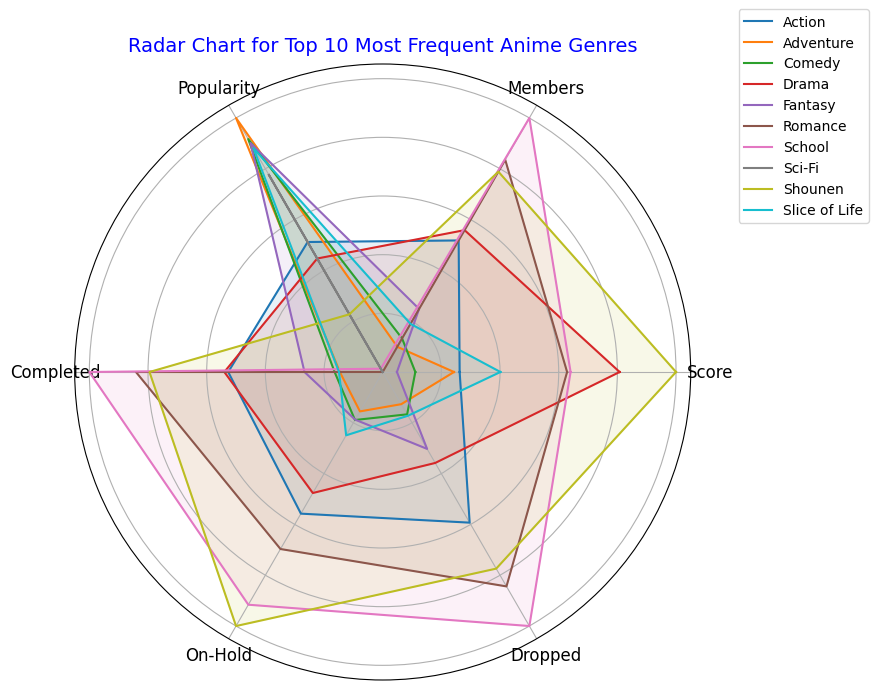

In [5]:
df = pd.read_csv("../../data/anime-filtered.csv")

# Explode the Genres column to assign each anime to multiple genres
df_exploded = df.assign(Genres=df['Genres'].str.split(', ')).explode('Genres')

# Count the frequency of each genre and select the top 10 most frequent ones
top_genres = df_exploded['Genres'].value_counts().head(10).index

# Filter dataset to include only the top 10 genres
df_exploded = df_exploded[df_exploded['Genres'].isin(top_genres)]

# Select relevant numerical columns
columns = ['Score', 'Members', 'Popularity', 'Completed', 'On-Hold', 'Dropped']

# Aggregate by genre, computing the mean for each variable
df_genre_avg_original = df_exploded.groupby('Genres')[columns].mean().reset_index()

# Store the original mean data before normalization
df_genre_avg = df_genre_avg_original.copy()

# Normalize values for better visualization (Min-Max Scaling)
df_genre_avg[columns] = (df_genre_avg[columns] - df_genre_avg[columns].min()) / \
                        (df_genre_avg[columns].max() - df_genre_avg[columns].min())

# Number of variables
num_vars = len(columns)

# Compute angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Close the circle

# Create the radar chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Define a color map for genres
colors = plt.cm.get_cmap("tab10", len(df_genre_avg))  # Use tab10 colormap

# Plot each of the top 10 genres
for i, row in df_genre_avg.iterrows():
    values = row[columns].values.flatten().tolist()
    values += values[:1]  # Close the circle

    ax.plot(angles, values, linewidth=1.5, linestyle='solid', label=row['Genres'], color=colors(i))
    ax.fill(angles, values, alpha=0.1, color=colors(i))  # Fill area lightly

# Set labels for each axis
ax.set_xticks(angles[:-1])
ax.set_xticklabels(columns, fontsize=12)

# Hide y-axis labels
ax.set_yticklabels([])

# Set title
ax.set_title("Radar Chart for Top 10 Most Frequent Anime Genres", size=14, color='blue', va='bottom')

# Add legend outside the plot
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.show()



In [3]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

def generate_radar(df):
    # Explode the Genres column to assign each anime to multiple genres
    df_exploded = df.assign(Genres=df['Genres'].str.split(', ')).explode('Genres')

    # Count the frequency of each genre and select the top 10 most frequent ones
    top_genres = df_exploded['Genres'].value_counts().head(10).index

    # Filter dataset to include only the top 10 genres
    df_exploded = df_exploded[df_exploded['Genres'].isin(top_genres)]

    # Select relevant numerical columns
    columns = ['Score', 'Members', 'Popularity', 'Completed', 'On-Hold', 'Dropped']

    # Aggregate by genre, computing the mean for each variable
    df_genre_avg = df_exploded.groupby('Genres')[columns].mean().reset_index()

    # Normalize values for better visualization (Min-Max Scaling)
    df_genre_avg[columns] = (df_genre_avg[columns] - df_genre_avg[columns].min()) / \
                            (df_genre_avg[columns].max() - df_genre_avg[columns].min())

    # Compute angle for each axis
    num_vars = len(columns)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Close the circle

    # Create the radar chart
    fig = go.Figure()

    # Plot each of the top 10 genres
    for _, row in df_genre_avg.iterrows():
        values = row[columns].values.flatten().tolist()
        values += values[:1]  # Close the circle

        fig.add_trace(go.Scatterpolar(
            r=values,
            theta=columns + [columns[0]],
            fill='toself',
            name=row['Genres']
        ))

    # Update layout
    fig.update_layout(
        polar=dict(
            radialaxis=dict(visible=True)
        ),
        title="Radar Chart for Top 10 Most Frequent Anime Genres",
        showlegend=True
    )
    
    return fig

generate_radar(df)

In [6]:
df_genre_avg_original

,Genres,Score,Members,Popularity,Completed,On-Hold,Dropped
0,Action,6.723658,73054.542872,5821.529743,47808.727492,2055.350482,2537.760450
1,Adventure,6.716735,49235.019897,7006.458364,32571.523213,1465.653648,1689.389094
2,Comedy,6.669055,51108.738014,6804.930688,33283.676243,1515.250135,1762.130903
3,Drama,6.920768,75360.265866,5663.919811,48337.703688,1936.261578,2110.322470
4,Fantasy,6.646423,57712.092375,6767.971784,37393.598925,1513.335237,2009.664427
5,Romance,6.856050,91125.386388,4579.979636,60404.613612,2259.332797,2994.201501
6,School,6.860338,100485.910569,4611.414009,66763.030019,2580.589118,3277.953721
7,Sci-Fi,6.628856,43587.188394,6470.378423,26719.341234,1238.386596,1459.064160
8,Shounen,6.990245,88459.125638,5131.136364,58555.689479,2703.535751,2866.881001
9,Slice of Life,6.773896,54367.880492,6718.858817,32682.115993,1603.585823,1772.349151


In [6]:
df_genre_avg

,Genres,Score,Members,Popularity,Completed,On-Hold,Dropped
0,Action,0.262326,0.517891,0.511667,0.526659,0.557598,0.593052
1,Adventure,0.243172,0.099261,1.000000,0.146145,0.155115,0.126629
2,Comedy,0.111237,0.132192,0.916946,0.163929,0.188966,0.166622
3,Drama,0.807749,0.558415,0.446713,0.539869,0.476317,0.358053
4,Fantasy,0.048609,0.248246,0.901715,0.266565,0.187659,0.302712
5,Romance,0.628670,0.835488,0.000000,0.841213,0.696821,0.843997
6,School,0.640533,1.000000,0.012955,1.000000,0.916086,1.000000
7,Sci-Fi,0.000000,0.000000,0.779071,0.000000,0.000000,0.000000
8,Shounen,1.000000,0.788628,0.227143,0.795040,1.000000,0.773998
9,Slice of Life,0.401340,0.189472,0.881475,0.148907,0.249257,0.172240
